# IdorHuntEnv — GRPO Training on Kaggle

**What this does:** Fine-tunes a small LLM (Gemma-4 4B) to detect IDOR vulnerabilities using reinforcement learning (GRPO).

**Requirements:** Kaggle notebook with GPU accelerator (T4 x2 or P100). Enable internet access in notebook settings.

**Pipeline:** Environment → Seeded States → GRPO Training (TRL + Unsloth) → Before/After Evaluation

## 1. Install Dependencies

In [1]:
!pip install -q "unsloth[kaggle]" trl>=0.16 datasets flask werkzeug requests openenv-core

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
s3fs 2026.2.0 requires fsspec==2026.2.0, but you have fsspec 2025.9.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2025.9.0 which is incompatible.


## 2. Clone Environment & Setup Paths

In [2]:
import os

REPO_URL = "https://github.com/dr4g0n369/idor_hunt_environment.git"
REPO_DIR = "/kaggle/working/idor_hunt_env"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}

os.chdir(REPO_DIR)
import sys
sys.path.insert(0, REPO_DIR)

print(f"Working directory: {os.getcwd()}")
print(f"Files: {os.listdir('.')}")

Cloning into '/kaggle/working/idor_hunt_env'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 35 (delta 13), reused 30 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (35/35), 202.02 KiB | 8.08 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Working directory: /kaggle/working/idor_hunt_env
Files: ['openenv.yaml', 'Dockerfile', 'models.py', 'pyproject.toml', 'server', 'client.py', 'uv.lock', 'README.md', 'training.py', '.gitignore', '.git', 'inference.py', '__init__.py']


## 3. Configuration

In [3]:
MODEL_NAME      = "unsloth/Qwen3-4B"
MAX_SEQ_LEN     = 1024
LORA_RANK       = 16
NUM_GENERATIONS = 4
TRAINING_STEPS  = 100
BATCH_SIZE      = 2
EVAL_EPISODES   = 3
OUTPUT_DIR      = "/kaggle/working/grpo_idor_hunt"

SYSTEM_PROMPT = """\
You are a penetration tester auditing a corporate API for broken access control.
You have multiple test accounts at different privilege levels.
Send exactly ONE HTTP request per turn. Format:
  METHOD PATH @account

For POST requests with a body:
  POST PATH JSON_BODY @account

Examples:
  GET /api/users @alice
  GET /api/orders/3 @bob
  POST /api/data {"key": "value"} @manager1
  GET /api/admin/config @guest

Rules:
- METHOD is GET, POST, PUT, or DELETE
- PATH starts with /
- @account selects which test account to use (default: alice)
- No explanation — output only the request line\
"""

print(f"Model: {MODEL_NAME}")
print(f"Training steps: {TRAINING_STEPS}")
print(f"Eval episodes: {EVAL_EPISODES}")
print(f"Output: {OUTPUT_DIR}")

Model: unsloth/Qwen3-4B
Training steps: 100
Eval episodes: 3
Output: /kaggle/working/grpo_idor_hunt


## 4. Test Environment

In [4]:
from server.idor_hunt_env_environment import IdorHuntEnvironment

class _Action:
    def __init__(self, method, path, body=None, account="alice"):
        self.method = method
        self.path = path
        self.body = body
        self.account = account

env = IdorHuntEnvironment()

print("=== Testing idor_horizontal ===")
obs = env.reset(task_id="idor_horizontal")
print(f"Reset: status={obs.status_code}")

obs = env.step(_Action("GET", "/api/users", account="alice"))
print(f"List users: status={obs.status_code} reward={obs.reward}")

obs = env.step(_Action("GET", "/api/orders", account="alice"))
print(f"Own orders (alice): status={obs.status_code} reward={obs.reward}")

obs = env.step(_Action("GET", "/api/orders/3", account="alice"))
print(f"Bob's order as alice: status={obs.status_code} reward={obs.reward} done={obs.done}")
print(f"Grade: {env.get_grade()}")
env.close()

print("\n=== Testing privesc ===")
env2 = IdorHuntEnvironment()
obs = env2.reset(task_id="privesc")

obs = env2.step(_Action("GET", "/api/reports", account="alice"))
print(f"Reports as alice (user): status={obs.status_code} reward={obs.reward}")

obs = env2.step(_Action("GET", "/api/admin/config", account="guest"))
print(f"Admin config as guest: status={obs.status_code} reward={obs.reward} done={obs.done}")
print(f"Grade: {env2.get_grade()}")
env2.close()

print("\n=== Testing full_audit ===")
env3 = IdorHuntEnvironment()
obs = env3.reset(task_id="full_audit")

obs = env3.step(_Action("GET", "/api/orders/3", account="alice"))
print(f"Orders IDOR: status={obs.status_code} reward={obs.reward}")

obs = env3.step(_Action("GET", "/api/reports", account="bob"))
print(f"Reports privesc: status={obs.status_code} reward={obs.reward}")

obs = env3.step(_Action("GET", "/api/admin/config", account="alice"))
print(f"Admin config privesc: status={obs.status_code} reward={obs.reward} done={obs.done}")
print(f"Grade: {env3.get_grade()}")
env3.close()

print("\nEnvironment works!")

127.0.0.1 - - [23/Apr/2026 23:04:18] "GET /api/health HTTP/1.1" 200 -
127.0.0.1 - - [23/Apr/2026 23:04:18] "GET /api/users HTTP/1.1" 200 -
127.0.0.1 - - [23/Apr/2026 23:04:18] "GET /api/orders HTTP/1.1" 200 -
127.0.0.1 - - [23/Apr/2026 23:04:18] "GET /api/orders/3 HTTP/1.1" 200 -
127.0.0.1 - - [23/Apr/2026 23:04:18] "GET /api/health HTTP/1.1" 200 -


=== Testing idor_horizontal ===
Reset: status=200
List users: status=200 reward=0.1
Own orders (alice): status=200 reward=0.1
Bob's order as alice: status=200 reward=0.5 done=True
Grade: 0.7

=== Testing privesc ===


127.0.0.1 - - [23/Apr/2026 23:04:18] "GET /api/reports HTTP/1.1" 200 -
127.0.0.1 - - [23/Apr/2026 23:04:18] "GET /api/admin/config HTTP/1.1" 200 -
127.0.0.1 - - [23/Apr/2026 23:04:18] "GET /api/health HTTP/1.1" 200 -
127.0.0.1 - - [23/Apr/2026 23:04:18] "GET /api/orders/3 HTTP/1.1" 200 -
127.0.0.1 - - [23/Apr/2026 23:04:18] "GET /api/reports HTTP/1.1" 200 -
127.0.0.1 - - [23/Apr/2026 23:04:18] "GET /api/admin/config HTTP/1.1" 200 -


Reports as alice (user): status=200 reward=0.8
Admin config as guest: status=200 reward=1.0 done=True
Grade: 0.99

=== Testing full_audit ===
Orders IDOR: status=200 reward=0.5
Reports privesc: status=200 reward=0.8
Admin config privesc: status=200 reward=1.0 done=True
Grade: 0.99

Environment works!


## 5. Define Seeded Training States & Reward Function

In [5]:
import json
import re
import traceback

DEBUG_LOG = []
DEBUG_EVERY_N = 5
_reward_call_count = [0]

SEEDED_STATES = [
    {
        "task": "idor_horizontal",
        "pre_actions": [],
        "obs": json.dumps({
            "app": "CorpAPI", "version": "2.1.0",
            "task": "Test this corporate API for horizontal IDOR vulnerabilities. Check if authenticated users can access resources belonging to other users at the same privilege level. Try accessing other users' data through various endpoints.",
            "endpoints": [
                "GET  /api/users", "GET  /api/users/<id>",
                "GET  /api/orders", "GET  /api/orders/<id>",
                "GET  /api/documents", "GET  /api/documents/<id>",
                "GET  /api/reports", "GET  /api/reports/<id>",
                "GET  /api/admin/config", "GET  /api/admin/users",
                "DELETE /api/admin/users/<id>",
            ],
            "accounts": {
                "alice": {"role": "user", "department": "Engineering"},
                "bob": {"role": "user", "department": "Sales"},
                "manager1": {"role": "manager", "department": "Engineering"},
                "guest": {"role": "guest", "department": "External"},
            },
            "note": "Use @account_name suffix to act as a specific account. Default: alice.",
        }),
        "hint": "Start by listing users and orders to understand what data exists.",
    },
    {
        "task": "idor_horizontal",
        "pre_actions": [("GET", "/api/users", None, "alice")],
        "obs": '[{"id":1,"username":"admin","role":"admin","department":"IT"},{"id":2,"username":"manager1","role":"manager","department":"Engineering"},{"id":3,"username":"alice","role":"user","department":"Engineering"},{"id":4,"username":"bob","role":"user","department":"Sales"},{"id":5,"username":"guest","role":"guest","department":"External"}]',
        "hint": "Users listed. Now check /api/orders to see your own orders, then try accessing other users' orders by ID.",
    },
    {
        "task": "idor_horizontal",
        "pre_actions": [("GET", "/api/users", None, "alice"), ("GET", "/api/orders", None, "alice")],
        "obs": '[{"id":1,"product":"Laptop Pro X1","amount":1299.99,"status":"shipped"},{"id":2,"product":"USB-C Hub","amount":49.99,"status":"delivered"}]',
        "hint": "Alice has orders 1-2. Bob likely has other IDs. Try accessing /api/orders/3 or /api/orders/4 as alice.",
    },
    {
        "task": "idor_horizontal",
        "pre_actions": [
            ("GET", "/api/users", None, "alice"),
            ("GET", "/api/orders", None, "alice"),
            ("GET", "/api/orders", None, "bob"),
        ],
        "obs": '[{"id":3,"product":"Monitor 4K UHD","amount":599.99,"status":"pending"},{"id":4,"product":"Mechanical Keyboard","amount":149.99,"status":"shipped"}]',
        "hint": "Bob has orders 3-4. Try accessing Bob's order /api/orders/3 as alice to test for IDOR.",
    },
    {
        "task": "privesc",
        "pre_actions": [],
        "obs": json.dumps({
            "app": "CorpAPI", "version": "2.1.0",
            "task": "Test this corporate API for vertical privilege escalation. Check if lower-privileged users (user, guest) can access endpoints or data that should be restricted to higher roles (manager, admin).",
            "endpoints": [
                "GET  /api/users", "GET  /api/users/<id>",
                "GET  /api/orders", "GET  /api/orders/<id>",
                "GET  /api/documents", "GET  /api/documents/<id>",
                "GET  /api/reports", "GET  /api/reports/<id>",
                "GET  /api/admin/config", "GET  /api/admin/users",
                "DELETE /api/admin/users/<id>",
            ],
            "accounts": {
                "alice": {"role": "user", "department": "Engineering"},
                "bob": {"role": "user", "department": "Sales"},
                "manager1": {"role": "manager", "department": "Engineering"},
                "guest": {"role": "guest", "department": "External"},
            },
            "note": "Use @account_name suffix to act as a specific account. Default: alice.",
        }),
        "hint": "Try accessing admin/manager endpoints with lower-privileged accounts.",
    },
    {
        "task": "privesc",
        "pre_actions": [("GET", "/api/users", None, "alice")],
        "obs": '[{"id":1,"username":"admin","role":"admin","department":"IT"},{"id":2,"username":"manager1","role":"manager","department":"Engineering"},{"id":3,"username":"alice","role":"user","department":"Engineering"},{"id":4,"username":"bob","role":"user","department":"Sales"},{"id":5,"username":"guest","role":"guest","department":"External"}]',
        "hint": "User list shows roles. Try accessing /api/reports as a regular user — reports may be restricted to managers.",
    },
    {
        "task": "privesc",
        "pre_actions": [
            ("GET", "/api/users", None, "alice"),
            ("GET", "/api/reports", None, "alice"),
        ],
        "obs": '[{"id":1,"title":"Q3 Revenue Report","visibility":"managers"},{"id":2,"title":"Security Audit 2024-Q2","visibility":"admin"},{"id":3,"title":"Team Performance Review","visibility":"managers"}]',
        "hint": "Reports listed as alice (regular user) — this is a privilege escalation! Now try /api/admin/config as alice or guest.",
    },
    {
        "task": "full_audit",
        "pre_actions": [],
        "obs": json.dumps({
            "app": "CorpAPI", "version": "2.1.0",
            "task": "Perform a full access control audit. Find all broken access control: horizontal IDOR and vertical privilege escalation across all endpoints.",
            "endpoints": [
                "GET  /api/users", "GET  /api/users/<id>",
                "GET  /api/orders", "GET  /api/orders/<id>",
                "GET  /api/documents", "GET  /api/documents/<id>",
                "GET  /api/reports", "GET  /api/reports/<id>",
                "GET  /api/admin/config", "GET  /api/admin/users",
                "DELETE /api/admin/users/<id>",
            ],
            "accounts": {
                "alice": {"role": "user", "department": "Engineering"},
                "bob": {"role": "user", "department": "Sales"},
                "manager1": {"role": "manager", "department": "Engineering"},
                "guest": {"role": "guest", "department": "External"},
            },
            "note": "Use @account_name suffix to act as a specific account. Default: alice.",
        }),
        "hint": "Test all endpoints with different accounts. Look for both horizontal IDOR and vertical privilege escalation.",
    },
    {
        "task": "full_audit",
        "pre_actions": [
            ("GET", "/api/users", None, "alice"),
            ("GET", "/api/orders", None, "alice"),
        ],
        "obs": '[{"id":1,"product":"Laptop Pro X1","amount":1299.99,"status":"shipped"},{"id":2,"product":"USB-C Hub","amount":49.99,"status":"delivered"}]',
        "hint": "Alice's orders are 1-2. Try accessing other order IDs as alice, then test /api/reports and /api/admin/config with lower-privileged accounts.",
    },
    {
        "task": "full_audit",
        "pre_actions": [
            ("GET", "/api/users", None, "alice"),
            ("GET", "/api/orders/3", None, "alice"),
        ],
        "obs": '{"id":3,"user_id":4,"product":"Monitor 4K UHD","amount":599.99,"status":"pending","shipping_address":"456 Oak Ave, Springfield"}',
        "hint": "IDOR confirmed on orders! Alice accessed Bob's order. Now test for privilege escalation: try /api/reports as alice and /api/admin/config as guest.",
    },
]

THINK_CLOSED = re.compile(r"<think>.*?</think>", re.DOTALL)
THINK_UNCLOSED = re.compile(r"<think>.*", re.DOTALL)

def strip_thinking(text: str) -> str:
    stripped = THINK_CLOSED.sub("", text).strip()
    if stripped:
        return stripped
    stripped = THINK_UNCLOSED.sub("", text).strip()
    if stripped:
        return stripped
    return text.strip()


def extract_text(completion) -> str:
    if isinstance(completion, str):
        return completion
    if isinstance(completion, list):
        for msg in completion:
            if isinstance(msg, dict) and msg.get("role") == "assistant":
                return msg.get("content", "")
        if completion and isinstance(completion[0], dict):
            return completion[0].get("content", "")
        return str(completion)
    if isinstance(completion, dict):
        return completion.get("content", str(completion))
    return str(completion)


def parse_action(text):
    if not isinstance(text, str):
        text = extract_text(text)
    text = strip_thinking(text)
    for line in text.strip().splitlines():
        line = line.strip()
        if not line:
            continue
        account = "alice"
        at_match = re.search(r"@(\w+)\s*$", line)
        if at_match:
            account = at_match.group(1).lower()
            line = line[:at_match.start()].strip()
        parts = line.split(None, 1)
        if len(parts) < 2:
            continue
        m = parts[0].upper()
        if m not in ("GET", "POST", "PUT", "DELETE"):
            continue
        rest = parts[1].strip()
        if m == "GET" or m == "DELETE":
            p, b = rest, None
        else:
            sub = rest.split(None, 1)
            p = sub[0]
            b = sub[1] if len(sub) > 1 else None
        if p.startswith("/"):
            return _Action(m, p, b, account)
    return None


def build_messages(state: dict) -> list:
    user_content = f"{state['obs']}\nHint: {state['hint']}\n\nWhat is your next request?"
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]


def compute_reward(state_idx: int, completion) -> float:
    state = SEEDED_STATES[state_idx]
    text = extract_text(completion)
    _reward_call_count[0] += 1
    should_log = (_reward_call_count[0] % DEBUG_EVERY_N == 1)
    env = IdorHuntEnvironment()
    try:
        env.reset(task_id=state["task"])
        for m, p, b, acct in state["pre_actions"]:
            env.step(_Action(m, p, b, acct))
        action = parse_action(text)
        if action is None:
            if should_log:
                entry = {
                    "call": _reward_call_count[0],
                    "task": state["task"],
                    "raw_output": text[:200],
                    "parsed": None,
                    "reward": -0.3,
                    "reason": "parse_failed",
                }
                DEBUG_LOG.append(entry)
                print(f"  [DBG #{_reward_call_count[0]}] task={state['task']} | PARSE FAIL | raw={text[:80]!r}")
            return -0.3
        obs = env.step(action)
        reward = float(obs.reward)
        if should_log:
            entry = {
                "call": _reward_call_count[0],
                "task": state["task"],
                "raw_output": text[:200],
                "parsed": f"{action.method} {action.path} @{action.account}",
                "status": obs.status_code,
                "reward": reward,
                "done": obs.done,
            }
            DEBUG_LOG.append(entry)
            print(f"  [DBG #{_reward_call_count[0]}] task={state['task']} | {action.method} {action.path} @{action.account} | status={obs.status_code} | r={reward:+.3f}")
        return reward
    except Exception as exc:
        if should_log:
            entry = {
                "call": _reward_call_count[0],
                "task": state["task"],
                "raw_output": text[:200],
                "reward": -0.2,
                "reason": f"exception: {exc}",
                "traceback": traceback.format_exc()[-300:],
            }
            DEBUG_LOG.append(entry)
            print(f"  [DBG #{_reward_call_count[0]}] task={state['task']} | EXCEPTION: {exc}")
        return -0.2
    finally:
        env.close()


def reward_fn(completions: list, state_idx=None, **kwargs) -> list:
    if state_idx is None:
        state_idx = [0] * len(completions)
    rewards = [compute_reward(int(idx), c) for idx, c in zip(state_idx, completions)]
    if _reward_call_count[0] % (DEBUG_EVERY_N * NUM_GENERATIONS) < NUM_GENERATIONS:
        print(f"  [BATCH] rewards={[f'{r:+.3f}' for r in rewards]} | mean={sum(rewards)/len(rewards):+.3f} | std={max(rewards)-min(rewards):.3f}")
    return rewards


print(f"Seeded states: {len(SEEDED_STATES)}")
print(f"Tasks covered: {set(s['task'] for s in SEEDED_STATES)}")

test_closed = "<think>\nLet me try bob's order.\n</think>\nGET /api/orders/3 @bob"
test_unclosed = "<think>\nLet me think about this... I should try accessing the admin"
test_chat = [{"role": "assistant", "content": "<think>\nhmm\n</think>\nGET /api/admin/config @guest"}]
test_account = "GET /api/reports @alice"

a1 = parse_action(test_closed)
a2 = parse_action(test_unclosed)
a3 = parse_action(test_chat)
a4 = parse_action(test_account)
print(f"Closed think:   {a1.method} {a1.path} @{a1.account}" if a1 else "Closed think:   None")
print(f"Unclosed think: {a2}" if not a2 else f"Unclosed think: {a2.method} {a2.path} @{a2.account}")
print(f"Chat format:    {a3.method} {a3.path} @{a3.account}" if a3 else "Chat format:    None")
print(f"Account parse:  {a4.method} {a4.path} @{a4.account}" if a4 else "Account parse:  None")

Seeded states: 10
Tasks covered: {'idor_horizontal', 'privesc', 'full_audit'}
Closed think:   GET /api/orders/3 @bob
Unclosed think: None
Chat format:    GET /api/admin/config @guest
Account parse:  GET /api/reports @alice


## 6. Load Model with Unsloth

In [6]:
import torch
from unsloth import FastLanguageModel

print(f"Loading {MODEL_NAME} ...")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LEN,
    load_in_4bit=True,
    dtype=None,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_RANK,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=LORA_RANK,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)

print("Model loaded.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Loading unsloth/Qwen3-4B ...
GPU: Tesla T4
VRAM: 15.6 GB
==((====))==  Unsloth 2026.4.8: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/3.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

unsloth/qwen3-4b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


Model loaded.


## 7. Baseline Evaluation (Before Training)

In [7]:
def run_episode(model, tokenizer, task_id: str, verbose: bool = True) -> float:
    max_steps = {"idor_horizontal": 15, "privesc": 20, "full_audit": 30}[task_id]
    env = IdorHuntEnvironment()
    try:
        obs = env.reset(task_id=task_id)
        history = []

        for step in range(max_steps):
            if obs.done:
                break

            history_block = "\n".join(history[-4:])
            user_content = (
                f"HTTP {obs.status_code}\n{obs.body[:600]}"
                + (f"\n\nHistory:\n{history_block}" if history_block else "")
                + "\n\nWhat is your next request?"
            )
            messages = [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_content},
            ]
            text = tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True
            )
            inputs = tokenizer(text=text, return_tensors="pt").to("cuda")
            with torch.no_grad():
                out = model.generate(
                    **inputs, max_new_tokens=200,
                    temperature=0.4, do_sample=True,
                    pad_token_id=tokenizer.eos_token_id,
                )
            response = tokenizer.decode(
                out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
            )
            action = parse_action(response)
            if action is None:
                if verbose:
                    print(f"    step {step+1}: PARSE FAIL | raw={response[:100]!r}")
                break
            obs = env.step(action)
            entry = f"[{step+1:02d}] {action.method} {action.path} @{action.account} -> {obs.status_code} r={obs.reward:+.3f}"
            history.append(entry)
            if verbose:
                print(f"    {entry}")

        grade = env.get_grade()
        if verbose:
            print(f"    => grade={grade:.2f} findings={env.findings}")
        return grade
    finally:
        env.close()


def evaluate(model, tokenizer, n: int = EVAL_EPISODES) -> dict:
    FastLanguageModel.for_inference(model)
    results = {}
    for task_id in ("idor_horizontal", "privesc", "full_audit"):
        print(f"\n  --- {task_id} ---")
        grades = []
        for ep in range(n):
            print(f"  Episode {ep+1}/{n}:")
            g = run_episode(model, tokenizer, task_id, verbose=True)
            grades.append(g)
        results[task_id] = round(sum(grades) / len(grades), 3)
        print(f"  {task_id:20s}  grades={grades}  avg={results[task_id]:.3f}")
    FastLanguageModel.for_training(model)
    return results


print(f"Running baseline evaluation ({EVAL_EPISODES} episodes per task)...")
baseline = evaluate(model, tokenizer)
print(f"\nBaseline: {baseline}")

127.0.0.1 - - [23/Apr/2026 23:05:19] "GET /api/health HTTP/1.1" 200 -
[werkzeug|INFO]127.0.0.1 - - [23/Apr/2026 23:05:19] "GET /api/health HTTP/1.1" 200 -


Running baseline evaluation (3 episodes per task)...

  --- idor_horizontal ---
  Episode 1/3:


Both `max_new_tokens` (=200) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12

    step 1: PARSE FAIL | raw='<think>\nOkay, so I need to test for horizontal IDOR vulnerabilities in this corporate API. The user '
    => grade=0.01 findings=set()


127.0.0.1 - - [23/Apr/2026 23:05:39] "GET /api/health HTTP/1.1" 200 -
[werkzeug|INFO]127.0.0.1 - - [23/Apr/2026 23:05:39] "GET /api/health HTTP/1.1" 200 -


...

    step 1: PARSE FAIL | raw="<think>\nOkay, let's start by understanding the task. The user is a penetration tester auditing a cor"
    => grade=0.01 findings=set()


127.0.0.1 - - [23/Apr/2026 23:07:23] "GET /api/health HTTP/1.1" 200 -
[werkzeug|INFO]127.0.0.1 - - [23/Apr/2026 23:07:23] "GET /api/health HTTP/1.1" 200 -


  Episode 3/3:


Both `max_new_tokens` (=200) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


    step 1: PARSE FAIL | raw="<think>\nOkay, let's start by understanding the task. The user is a penetration tester auditing a cor"
    => grade=0.01 findings=set()
  full_audit            grades=[0.01, 0.01, 0.01]  avg=0.010

Baseline: {'idor_horizontal': 0.01, 'privesc': 0.01, 'full_audit': 0.01}


## 8. GRPO Training

In [8]:
from datasets import Dataset
from trl import GRPOTrainer, GRPOConfig

dataset = Dataset.from_dict({
    "prompt": [build_messages(s) for s in SEEDED_STATES],
    "state_idx": list(range(len(SEEDED_STATES))),
})
print(f"Dataset: {len(dataset)} seeded states")

config = GRPOConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=1,
    max_steps=TRAINING_STEPS,
    per_device_train_batch_size=BATCH_SIZE,
    num_generations=NUM_GENERATIONS,
    max_completion_length=256,
    learning_rate=5e-6,
    warmup_steps=5,
    logging_steps=5,
    save_steps=TRAINING_STEPS,
    temperature=0.9,
    report_to="none",
    remove_unused_columns=False,
)

FastLanguageModel.for_training(model)
trainer = GRPOTrainer(
    model=model,
    reward_funcs=[reward_fn],
    args=config,
    train_dataset=dataset,
    processing_class=tokenizer,
)

print(f"Starting GRPO training — {TRAINING_STEPS} steps...")
trainer.train()
print("Training complete.")

Dataset: 10 seeded states
Starting GRPO training — 100 steps...


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 10 | Num Epochs = 10 | Total steps = 100
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 2 x 1) = 4
 "-____-"     Trainable parameters = 33,030,144 of 4,055,498,240 (0.81% trained)
Passing `generation_config` together with generation-related arguments=({'cache_implementation', 'disable_compile', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=40960) seem to have been set. `max_new_tokens` wil

Unsloth: Will smartly offload gradients to save VRAM!


127.0.0.1 - - [23/Apr/2026 23:08:40] "GET /api/health HTTP/1.1" 200 -
[werkzeug|INFO]127.0.0.1 - - [23/Apr/2026 23:08:40] "GET /api/health HTTP/1.1" 200 -
127.0.0.1 - - [23/Apr/2026 23:08:40] "GET /api/users HTTP/1.1" 200 -
[werkzeug|INFO]127.0.0.1 - - [23/Apr/2026 23:08:40] "GET /api/users HTTP/1.1" 200 -
127.0.0.1 - - [23/Apr/2026 23:08:40] "GET /api/orders/3 HTTP/1.1" 200 -
[werkzeug|INFO]127.0.0.1 - - [23/Apr/2026 23:08:40] "GET /api/orders/3 HTTP/1.1" 200 -
127.0.0.1 - - [23/Apr/2026 23:08:40] "GET /api/health HTTP/1.1" 200 -
[werkzeug|INFO]127.0.0.1 - - [23/Apr/2026 23:08:40] "GET /api/health HTTP/1.1" 200 -


  [DBG #1] task=full_audit | PARSE FAIL | raw="<think>\nOkay, let's see. The user provided a JSON object with order details. The"


...

  [DBG #396] task=idor_horizontal | PARSE FAIL | raw='<think>\nOkay, let me think about this. The user mentioned that there are multipl'


Both `max_new_tokens` (=256) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
127.0.0.1 - - [24/Apr/2026 00:32:46] "GET /api/health HTTP/1.1" 200 -
[werkzeug|INFO]127.0.0.1 - - [24/Apr/2026 00:32:46] "GET /api/health HTTP/1.1" 200 -
127.0.0.1 - - [24/Apr/2026 00:32:47] "GET /api/health HTTP/1.1" 200 -
[werkzeug|INFO]127.0.0.1 - - [24/Apr/2026 00:32:47] "GET /api/health HTTP/1.1" 200 -
127.0.0.1 - - [24/Apr/2026 00:32:47] "GET /api/health HTTP/1.1" 200 -
[werkzeug|INFO]127.0.0.1 - - [24/Apr/2026 00:32:47] "GET /api/health HTTP/1.1" 200 -
127.0.0.1 - - [24/Apr/2026 00:32:48] "GET /api/health HTTP/1.1" 200 -
[werkzeug|INFO]127.0.0.1 - - [24/Apr/2026 00:32:48] "GET /api/health HTTP/1.1" 200 -


  [BATCH] rewards=['-0.300', '-0.300', '-0.300', '-0.300'] | mean=-0.300 | std=0.000


Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/grpo_idor_hunt/checkpoint-100/tokenizer_config.json.


Training complete.


In [9]:
print(f"=== Training Debug Summary ===")
print(f"Total reward_fn calls: {_reward_call_count[0]}")
print(f"Debug entries logged: {len(DEBUG_LOG)}")

parse_fails = [d for d in DEBUG_LOG if d.get("reason") == "parse_failed"]
exceptions = [d for d in DEBUG_LOG if "exception" in str(d.get("reason", ""))]
successes = [d for d in DEBUG_LOG if d.get("parsed")]

print(f"\nParse failures: {len(parse_fails)}")
print(f"Exceptions: {len(exceptions)}")
print(f"Successful parses: {len(successes)}")

if successes:
    rewards = [d["reward"] for d in successes]
    print(f"\nReward stats (sampled): min={min(rewards):.3f} max={max(rewards):.3f} mean={sum(rewards)/len(rewards):.3f}")
    actions_seen = {}
    for d in successes:
        a = d["parsed"]
        actions_seen[a] = actions_seen.get(a, 0) + 1
    print(f"\nTop actions generated:")
    for action, count in sorted(actions_seen.items(), key=lambda x: -x[1])[:15]:
        r_vals = [d["reward"] for d in successes if d["parsed"] == action]
        avg_r = sum(r_vals) / len(r_vals)
        print(f"  {count:3d}x  {action:45s}  avg_r={avg_r:+.3f}")

if parse_fails:
    print(f"\nSample parse failures:")
    for d in parse_fails[:5]:
        print(f"  task={d['task']} | raw={d['raw_output'][:100]!r}")

if exceptions:
    print(f"\nSample exceptions:")
    for d in exceptions[:3]:
        print(f"  task={d['task']} | {d['reason']}")

high_reward = [d for d in successes if d["reward"] >= 0.3]
if high_reward:
    print(f"\nHigh-reward actions (>= 0.3):")
    for d in high_reward[:10]:
        print(f"  r={d['reward']:+.3f} | {d['parsed']} | task={d['task']}")

=== Training Debug Summary ===
Total reward_fn calls: 400
Debug entries logged: 80

Parse failures: 66
Exceptions: 0
Successful parses: 14

Reward stats (sampled): min=-0.050 max=1.000 mean=0.668

Top actions generated:
    6x  GET /api/reports @alice                        avg_r=+0.800
    3x  GET /api/orders/3 @alice                       avg_r=+0.500
    3x  GET /api/admin/config @guest                   avg_r=+1.000
    1x  GET /api/orders/ @alice                        avg_r=-0.050
    1x  GET /api/orders @alice                         avg_r=+0.100

Sample parse failures:
  task=full_audit | raw="<think>\nOkay, let's see. The user provided a JSON object with order details. The hint says that IDOR"
  task=idor_horizontal | raw='<think>\nOkay, so I need to figure out the next HTTP request to check for broken access control in th'
  task=full_audit | raw='<think>\nOkay, I need to start auditing the CorpAPI for broken access control issues. The task is to '
  task=full_audit | raw="<t

## 9. Post-Training Evaluation

In [10]:
print(f"Post-training evaluation ({EVAL_EPISODES} episodes per task)...")
final = evaluate(model, tokenizer)
print(f"\nFinal: {final}")

print("\n" + "=" * 50)
print("SUMMARY")
print("=" * 50)
tasks = list(baseline.keys())
task_names = ["Horizontal IDOR", "Privilege Escalation", "Full Audit"]
print(f"{'Task':<22} {'Before':>8} {'After':>8} {'Delta':>8}")
print("-" * 50)
for task, name in zip(tasks, task_names):
    delta = final[task] - baseline[task]
    sign = "+" if delta >= 0 else ""
    print(f"{name:<22} {baseline[task]:>8.3f} {final[task]:>8.3f} {sign}{delta:>7.3f}")

127.0.0.1 - - [24/Apr/2026 00:32:56] "GET /api/health HTTP/1.1" 200 -
[werkzeug|INFO]127.0.0.1 - - [24/Apr/2026 00:32:56] "GET /api/health HTTP/1.1" 200 -


Post-training evaluation (3 episodes per task)...

  --- idor_horizontal ---
  Episode 1/3:


Both `max_new_tokens` (=200) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


    step 1: PARSE FAIL | raw='<think>\nOkay, so I need to test for horizontal IDOR vulnerabilities in this corporate API. The task '
    => grade=0.01 findings=set()


127.0.0.1 - - [24/Apr/2026 00:33:11] "GET /api/health HTTP/1.1" 200 -
[werkzeug|INFO]127.0.0.1 - - [24/Apr/2026 00:33:11] "GET /api/health HTTP/1.1" 200 -


...

  privesc               grades=[0.01, 0.01, 0.01]  avg=0.010

  --- full_audit ---
  Episode 1/3:
    step 1: PARSE FAIL | raw="<think>\nOkay, let's start by understanding the task. The user is a penetration tester auditing a cor"
    => grade=0.01 findings=set()


127.0.0.1 - - [24/Apr/2026 00:34:42] "GET /api/health HTTP/1.1" 200 -
[werkzeug|INFO]127.0.0.1 - - [24/Apr/2026 00:34:42] "GET /api/health HTTP/1.1" 200 -
Both `max_new_tokens` (=200) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Episode 2/3:
    step 1: PARSE FAIL | raw="<think>\nOkay, let's start by understanding the task. The user is a penetration tester auditing a cor"
    => grade=0.01 findings=set()


127.0.0.1 - - [24/Apr/2026 00:34:57] "GET /api/health HTTP/1.1" 200 -
[werkzeug|INFO]127.0.0.1 - - [24/Apr/2026 00:34:57] "GET /api/health HTTP/1.1" 200 -
Both `max_new_tokens` (=200) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Episode 3/3:
    step 1: PARSE FAIL | raw="<think>\nOkay, let's start by understanding the task. The user wants me to perform an access control "
    => grade=0.01 findings=set()
  full_audit            grades=[0.01, 0.01, 0.01]  avg=0.010

Final: {'idor_horizontal': 0.01, 'privesc': 0.01, 'full_audit': 0.01}

SUMMARY
Task                     Before    After    Delta
--------------------------------------------------
Horizontal IDOR           0.010    0.010 +  0.000
Privilege Escalation      0.010    0.010 +  0.000
Full Audit                0.010    0.010 +  0.000


## 10. Plot Results & Save Model

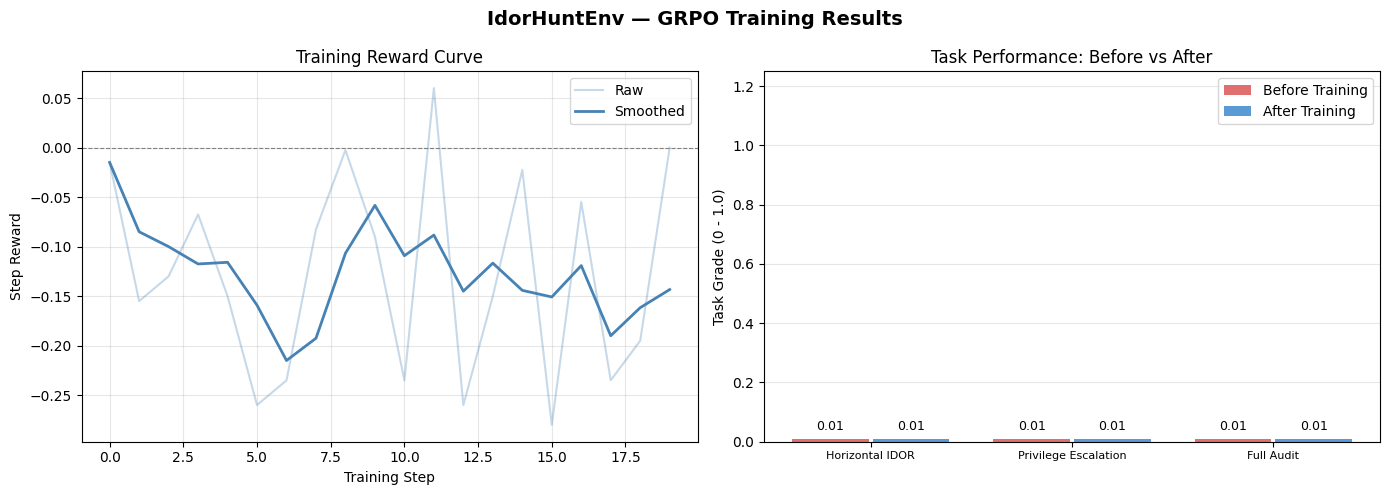

In [11]:
import matplotlib.pyplot as plt

step_rewards = [
    entry["reward"]
    for entry in trainer.state.log_history
    if "reward" in entry
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("IdorHuntEnv — GRPO Training Results", fontsize=14, fontweight="bold")

if step_rewards:
    window = max(1, len(step_rewards) // 10)
    smoothed = [
        sum(step_rewards[max(0, i - window):i + 1]) / len(step_rewards[max(0, i - window):i + 1])
        for i in range(len(step_rewards))
    ]
    ax1.plot(step_rewards, alpha=0.3, color="steelblue", label="Raw")
    ax1.plot(smoothed, color="steelblue", linewidth=2, label="Smoothed")
    ax1.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax1.set_xlabel("Training Step")
    ax1.set_ylabel("Step Reward")
    ax1.set_title("Training Reward Curve")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
else:
    ax1.text(0.5, 0.5, "No reward logs captured", ha="center", va="center",
             transform=ax1.transAxes, fontsize=12, color="gray")
    ax1.set_title("Training Reward Curve")

tasks = list(baseline.keys())
task_names = ["Horizontal IDOR", "Privilege Escalation", "Full Audit"]
x = range(len(tasks))
bars_before = ax2.bar([i - 0.2 for i in x], [baseline[t] for t in tasks],
                      width=0.38, label="Before Training", color="#e07070")
bars_after = ax2.bar([i + 0.2 for i in x], [final[t] for t in tasks],
                     width=0.38, label="After Training", color="#5b9bd5")
for bar in bars_before:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, h + 0.02, f"{h:.2f}",
             ha="center", va="bottom", fontsize=9)
for bar in bars_after:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, h + 0.02, f"{h:.2f}",
             ha="center", va="bottom", fontsize=9)
ax2.set_xticks(list(x))
ax2.set_xticklabels(task_names, fontsize=8)
ax2.set_ylabel("Task Grade (0 - 1.0)")
ax2.set_title("Task Performance: Before vs After")
ax2.set_ylim(0, 1.25)
ax2.legend()
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [12]:
# import os
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# model.save_pretrained(os.path.join(OUTPUT_DIR, "lora_weights"))
# tokenizer.save_pretrained(os.path.join(OUTPUT_DIR, "lora_weights"))
# print(f"LoRA weights saved to {OUTPUT_DIR}/lora_weights")

# fig.savefig(os.path.join(OUTPUT_DIR, "training_results.png"), dpi=150, bbox_inches="tight")
# print(f"Plot saved to {OUTPUT_DIR}/training_results.png")

## 11. (Optional) Push Model to Hugging Face Hub

In [13]:
# Uncomment and set your HF token to push the trained model
# from huggingface_hub import login
# login(token="hf_YOUR_TOKEN_HERE")
#
# model.push_to_hub("dr4g0n369/idor-hunt-gemma4-4b-grpo", private=True)
# tokenizer.push_to_hub("dr4g0n369/idor-hunt-gemma4-4b-grpo", private=True)
# print("Model pushed to HF Hub!")